Mount Google Drive

Connects Google Colab with Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Move to Working Directory

Changes current directory to the folder containing the dataset.

In [2]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


Load Dataset

Reads CSV file.
Converts Date column into datetime format.
Sets Date as index.

In [3]:
import pandas as pd
dataset=pd.read_csv("Tatacoffee13_21.csv", parse_dates=['Date'], index_col='Date')

In [4]:
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


Create Continuous Date Range

Creates all calendar dates between start and end date.

In [5]:
#Start date and end_date
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2013-01-01")
end_date = pd.to_datetime("2019-02-04") - timedelta(days=1) #Excluding last

#List of all dates
all_date = pd.date_range(start_date, end_date, freq='d')

In [6]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[ns]', length=2225, freq='D')

Assign New Date Index

Replaces existing index with continuous daily dates.

In [7]:
dummyDate=dataset

In [8]:
dummyDate.index=all_date

In [9]:
dummyDate

,Open,High,Low,Close
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-05,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2019-01-30,202.90,207.80,201.35,205.00
2019-01-31,206.00,206.85,202.05,202.95
2019-02-01,203.90,203.90,199.35,201.00
2019-02-02,200.00,222.00,196.00,218.35


In [10]:
#DateIndex.index=pd.to_datetime(dataset["Date"],infer_datetime_format=True)

Plot Closing Price

Visual inspection for:

Trend
Seasonality
Sudden changes

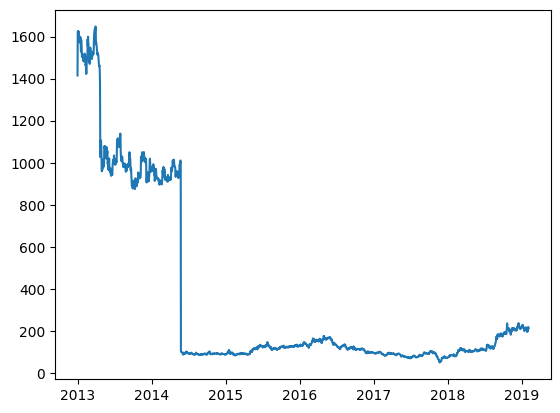

In [11]:
import matplotlib.pyplot as plt
plt.plot(dataset["Close"])

In [12]:
print(dummyDate.index)
print(type(dummyDate.index))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[ns]', length=2225, freq='D')
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


Seasonal Decomposition (Multiplicative)

Decomposes series into:

Observed=Trend×Seasonal×Residual

Shows:

Original Series
Trend
Seasonality
Residual

<Figure size 1600x500 with 0 Axes>

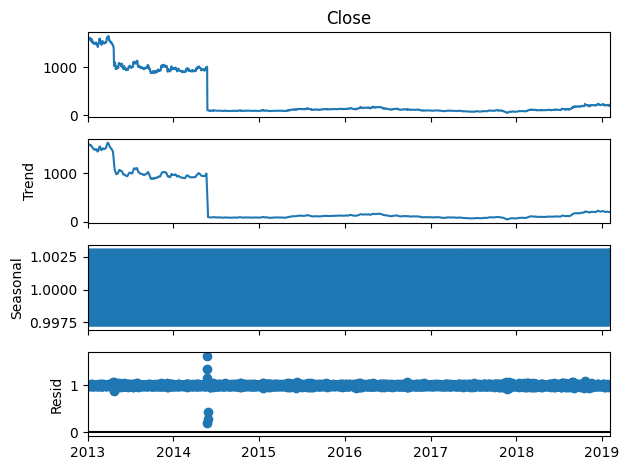

In [13]:
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

Seasonal Decomposition (Additive)

Formula:

Observed=Trend+Seasonal+Residual

Used when seasonal fluctuations remain constant.

<Figure size 1600x500 with 0 Axes>

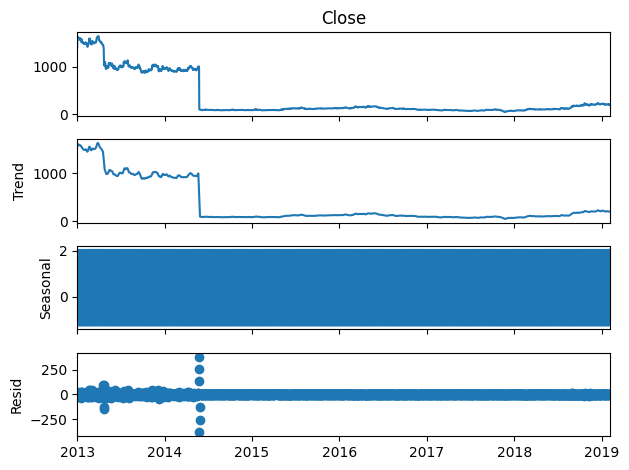

In [14]:
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

ADF Test (Stationarity Test)

In [15]:

# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries,df,pollutant):
    plt.figure(figsize=(16,5))
    # Plot the data
    # ADF Test
    # Function to print out results in customised manner
    from statsmodels.tsa.stattools import adfuller
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    ans=dfoutput
    print("Condition:")
    print("p-value<=0.05-->Accept Alternate Hypothesis")
    print("p-value>0.05-->Accept Null Hypothesis")
    if(ans['Test Statistic']<ans["Critical Value (1%)"] or ans['Test Statistic']<ans["Critical Value (5%)"] or ans['Test Statistic']<ans["Critical Value (10%)"] and ans["p-value"]<0.05):
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Reject null hypothesis:Non Stationarity")
        print("Accept Alternate hypothesis:Staionarity ")
        message="Stationarity based on ADH"
    else:
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Accept null hypothesis:Non Stationarity" )
        print("Reject Alternate hypothesis:Staionarity ")
        message="Non-stationarity based on ADH"

    plt.plot(df.index, df[pollutant], label = pollutant)
    plt.legend(loc='best')
    plt.title("{}_{}_2013 to 2021".format(message,pollutant))
    plt.savefig("{}_ADH.png".format(pollutant))
    plt.show()

    return message

# Call the function and run the test



ADF Test (Stationarity Test) Rule

| p-value | Result         |
| ------- | -------------- |
| ≤ 0.05  | Stationary     |
| > 0.05  | Non-Stationary |


Results of Dickey-Fuller Test:
Test Statistic                   -3.007236
p-value                           0.034224
#Lags Used                        1.000000
Number of Observations Used    2223.000000
Critical Value (1%)              -3.433295
Critical Value (5%)              -2.862841
Critical Value (10%)             -2.567463
dtype: float64
Condition:
p-value<=0.05-->Accept Alternate Hypothesis
p-value>0.05-->Accept Null Hypothesis
Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis
Reject null hypothesis:Non Stationarity
Accept Alternate hypothesis:Staionarity 


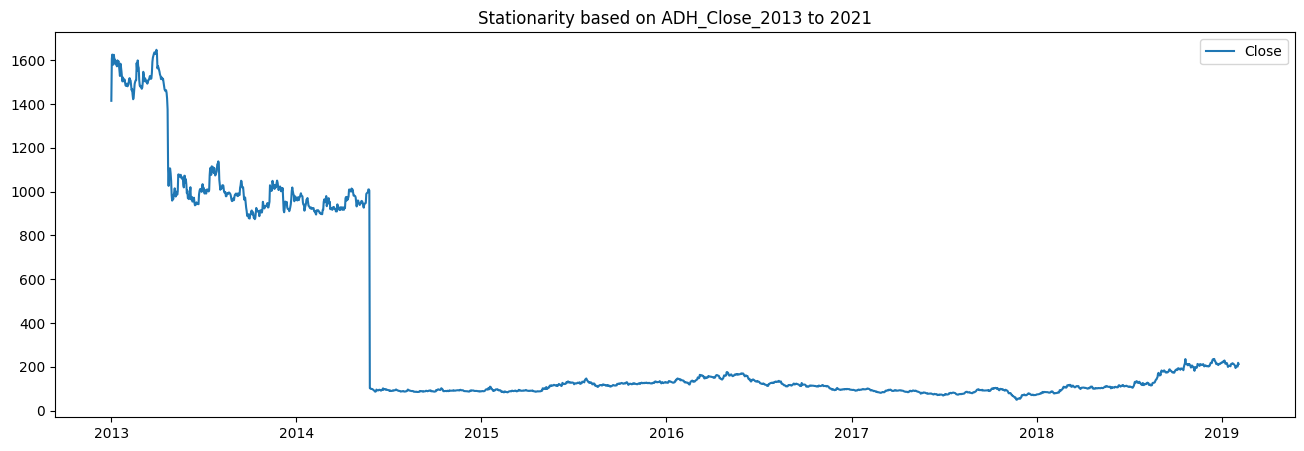

'Stationarity based on ADH'

In [16]:
adf_test(dataset["Close"],dataset,"Close")

ACF and PACF

ACF

Measures:

Correlation(Yt​,Yt−k​)

Used for MA(q).	​


PACF

Measures direct relationship after removing intermediate lags.

Used for AR(p).

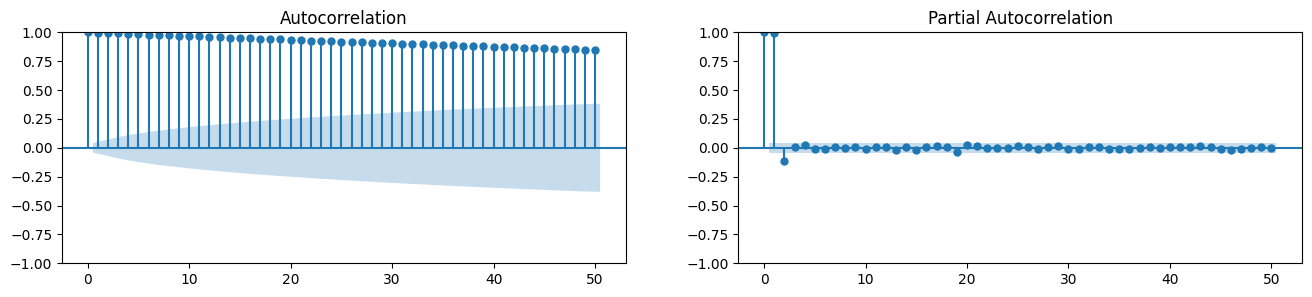

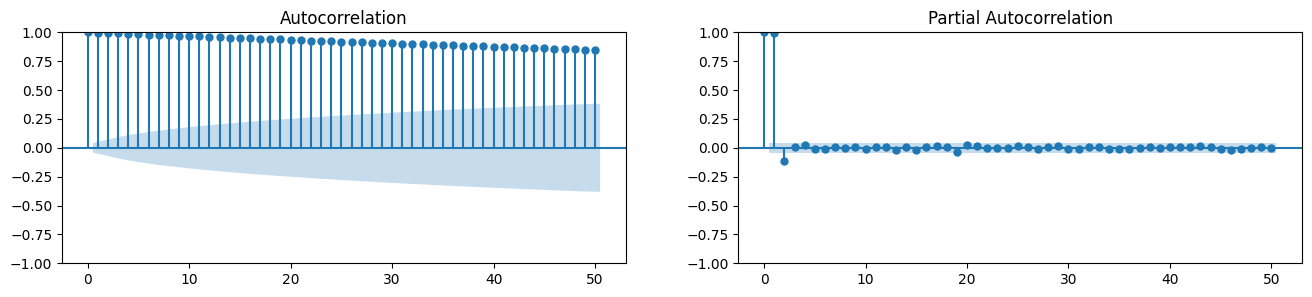

In [17]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(dataset.Close.tolist(), lags=50, ax=axes[0])
plot_pacf(dataset.Close.tolist(), lags=50, ax=axes[1])

ACF Line Plot

Shows correlation across lag values

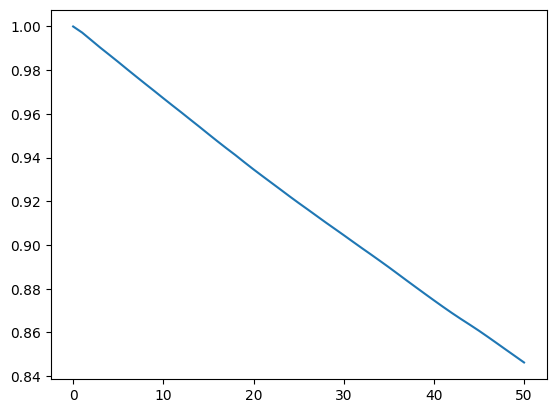

In [18]:
plt.plot(acf(dataset["Close"],nlags=50))

PACF Line Plot

Helps identify AR order.

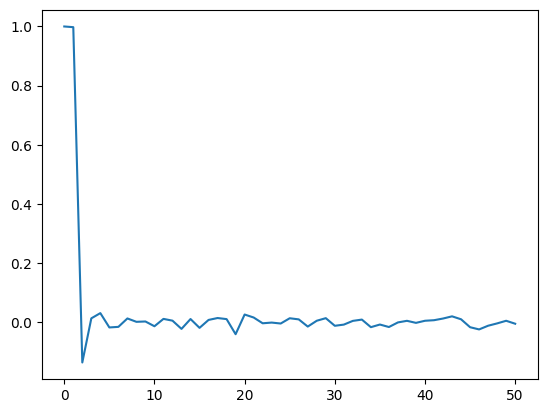

In [19]:
plt.plot(pacf(dataset["Close"],nlags=50))

Lag Plot

Checks autocorrelation visually.

| Shape         | Meaning                |
| ------------- | ---------------------- |
| Straight Line | Strong autocorrelation |
| Random Cloud  | Weak autocorrelation   |


<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

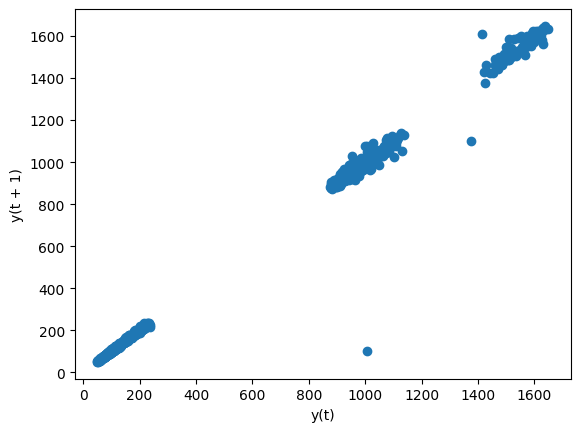

In [20]:
from pandas.plotting import lag_plot
lag_plot(dataset["Close"],lag=1)

## Forecastability

### Apen small- Forecastability is possible
### Spen Small-Forecastability is possible

Approximate Entropy (ApEn)

Measures randomness.

| Value | Meaning      |
| ----- | ------------ |
| Small | Forecastable |
| Large | Random       |


In [21]:
def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

In [22]:
import numpy as np
print(ApEn(dataset["Close"], m=2, r=0.2*np.std(dataset["Close"])))

/tmp/ipykernel_1175/2578661817.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]


0.027409184525792107


| ApEn Value | Interpretation      |
| ---------- | ------------------- |
| Near 0     | Highly predictable  |
| 0.1 - 0.5  | Moderate complexity |
| > 1        | Highly random       |

===========

0.0274 ≈ 0

✅ Very low randomness

✅ Strong underlying pattern exists

✅ Data points are highly similar to neighboring observations

✅ Time series is predictable

✅ Suitable for forecasting models such as:

ARIMA
SARIMA
Holt-Winters
Prophet
LSTM

Sample Entropy (SampEn)

Measures complexity.
| Value | Meaning     |
| ----- | ----------- |
| Small | Predictable |
| Large | Random      |


In [23]:
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

In [24]:
print(SampEn(dataset["Close"], m=2, r=0.2*np.std(dataset["Close"])))

/tmp/ipykernel_1175/1392444303.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]


0.007918086989927514


| SampEn Value | Interpretation                         |
| ------------ | -------------------------------------- |
| Near 0       | Highly predictable                     |
| 0.1 – 1.0    | Moderate complexity                    |
| > 1.0        | Highly random                          |
| > 2.0        | Very complex and difficult to forecast |

===========

0.03987 ≈ 0

✅ Very low complexity

✅ Very low randomness

✅ Strong repeating patterns exist

✅ High predictability

✅ Suitable for forecasting models

| Step No | Topic                        | Code/Function                                     | Purpose                           | Output/Conclusion           |
| ------- | ---------------------------- | ------------------------------------------------- | --------------------------------- | --------------------------- |
| 1       | Mount Drive                  | `drive.mount()`                                   | Connect Google Drive              | Access dataset              |
| 2       | Change Directory             | `%cd`                                             | Navigate to dataset folder        | Working directory set       |
| 3       | Load Dataset                 | `pd.read_csv()`                                   | Read stock data                   | DataFrame created           |
| 4       | Create Date Range            | `pd.date_range()`                                 | Generate continuous dates         | Daily date index            |
| 5       | Assign Index                 | `dummyDate.index=all_date`                        | Replace date index                | Continuous time series      |
| 6       | Time Series Plot             | `plt.plot()`                                      | Visualize stock prices            | Trend identification        |
| 7       | Multiplicative Decomposition | `seasonal_decompose(..., model='multiplicative')` | Extract Trend, Seasonal, Residual | Check seasonality           |
| 8       | Additive Decomposition       | `seasonal_decompose(..., model='additive')`       | Alternative decomposition         | Check seasonality           |
| 9       | ADF Test                     | `adfuller()`                                      | Test stationarity                 | Stationary / Non-stationary |
| 10      | ACF Plot                     | `plot_acf()`                                      | Measure autocorrelation           | MA(q) identification        |
| 11      | PACF Plot                    | `plot_pacf()`                                     | Measure partial autocorrelation   | AR(p) identification        |
| 12      | ACF Values                   | `acf()`                                           | Numerical correlation values      | Lag relationship            |
| 13      | PACF Values                  | `pacf()`                                          | Numerical partial correlation     | AR order detection          |
| 14      | Lag Plot                     | `lag_plot()`                                      | Visual autocorrelation check      | Pattern detection           |
| 15      | Approximate Entropy          | `ApEn()`                                          | Measure randomness                | Forecastability check       |
| 16      | Sample Entropy               | `SampEn()`                                        | Measure complexity                | Forecastability check       |


| Analysis                  | Function Used          | Result Meaning                |
| ------------------------- | ---------------------- | ----------------------------- |
| Trend Detection           | Time Series Plot       | Upward/Downward movement      |
| Seasonality Detection     | Seasonal Decomposition | Repeating patterns            |
| Stationarity Check        | ADF Test               | Required for ARIMA            |
| Autocorrelation Check     | ACF                    | Dependence on previous values |
| Partial Correlation Check | PACF                   | Direct lag influence          |
| Randomness Check          | Approximate Entropy    | Predictability                |
| Complexity Check          | Sample Entropy         | Forecastability               |


Project Conclusion

| Metric                     | Value  | Interpretation           |
| -------------------------- | ------ | ------------------------ |
| Approximate Entropy (ApEn) | 0.0274 | Low Randomness           |
| Sample Entropy (SampEn)    | 0.0399 | Low Complexity           |
| Forecastability            | High   | Suitable for Forecasting |

===========

The Tata Coffee closing-price time series exhibits low randomness, low complexity, and high predictability. Therefore, it is a strong candidate for forecasting using ARIMA, SARIMA, Prophet, XGBoost, and LSTM models.